# 강아지 고양이의 분류 모델, CNN DNN

In [1]:
# import 함수, torch device 설정
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

USE_MPS = torch.backends.mps.is_available()
DEVICE = torch.device("mps" if USE_MPS else "cpu")

In [2]:
# 데이터셋 생성 및 분할
class F_dataset(Dataset):
    def __init__(self, dir, transform=None):
        self.img_dir = dir
        self.img_f = list(self.img_dir.glob('*.jpg'))
        if len(self.img_f) == 0:
            print("로드할 파일이 없습니다.")
        self.transform = transform

    def __len__(self):
        return len(self.img_f)

    def __getitem__(self, idx):
        img_path = self.img_f[idx]

        image = Image.open(img_path).convert('RGB')

        label_name = img_path.stem.split('.')[0].lower()
        if label_name == 'cat':
            label = 0
        elif label_name == 'dog':
            label = 1
        else:
            raise ValueError(f'파일 클래스 내용이 없는 파일이 로드 되었습니다{img_path.name}')

        if self.transform:
            image = self.transform(image)

        return image, label

파일이_통합되어_있는_경로 = Path('../../data/dogs-vs-cats/train')

transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

all_ds = F_dataset(파일이_통합되어_있는_경로, transform)

all_ds_n = len(all_ds)
train_size = int(all_ds_n * 0.70)
val_size = int(all_ds_n * 0.15)
test_size = all_ds_n - train_size - val_size

train_dataset, temp_dataset = random_split(all_ds, [train_size, val_size + test_size])
val_dataset, test_dataset = random_split(temp_dataset, [val_size, test_size])

print(f"훈련 데이터: {len(train_dataset)}개")
print(f"검증 데이터: {len(val_dataset)}개")
print(f"테스트 데이터: {len(test_dataset)}개")

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

훈련 데이터: 17500개
검증 데이터: 3750개
테스트 데이터: 3750개


In [3]:
# DNN 함수
class DNN_Model(nn.Module):
    def __init__(self, input_n, hidden_ns, output_n, dropout_p=0.2):
        super().__init__()
        self.fc_in = (nn.Linear(input_n, hidden_ns[0]))
        self.fc_h_l = nn.ModuleList([nn.Linear(hidden_ns[i], hidden_ns[i + 1]) for i in range(len(hidden_ns) - 1)])
        self.fc_out = nn.Linear(hidden_ns[-1], output_n)

        self.dropout_p = dropout_p
        self.input_n = input_n
        self.hidden_ns = hidden_ns
        self.output_n = output_n

    def forward(self, x):
        x = x.view(-1, self.input_n)
        x = F.relu(self.fc_in(x))

        for i in range(len(self.fc_h_l)):
            x = F.relu(self.fc_h_l[i](x))
        out = self.fc_out(x)
        return out


In [4]:
# 모델 학습 전 컴파일
INPUT_SIZE = 3 * 100 * 100
model_dnn = DNN_Model(INPUT_SIZE, [256, 128, 68], 2).to(DEVICE)
opt = optim.Adam(model_dnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

In [5]:
# 학습과 예측 함수
def train(model, tr_ds_loader, opt, epoch):
    model.train()
    for i, (x, y) in enumerate(tr_ds_loader):
        data, target = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        py = model(data)
        loss = F.cross_entropy(py, target)
        loss.backward()
        opt.step()

@torch.no_grad()
def evaluate(model, tt_ds_loader):
    model.eval()
    test_loss = 0
    correct = 0
    for data, target in tt_ds_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        py = model(data)
        test_loss += F.cross_entropy(py, target, reduction='sum').item()
        pred = py.max(1, keepdim=True)[1]
        correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(tt_ds_loader.dataset)
    test_accuracy = correct / len(tt_ds_loader.dataset) * 100.
    return test_loss, test_accuracy


In [6]:
# 메인 함수
EPOCHS = 10

for i in range(1, EPOCHS + 1):
    train(model_dnn, train_loader, opt, i)
    val_loss, val_accuracy = evaluate(model_dnn, val_loader)
    scheduler.step()
    print(f'epoch: {i}, val_loss: {val_loss:.3f}, val_accuracy: {val_accuracy:.3f}, lr: {scheduler.get_last_lr()[0]}')

print("\n--- 최종 테스트 평가 ---")
final_loss, final_accuracy = evaluate(model_dnn, test_loader)
print(f'Final Test Loss: {final_loss:.3f}, Final Test Accuracy: {final_accuracy:.3f}')

epoch: 1, val_loss: 0.665, val_accuracy: 59.787, lr: 0.001
epoch: 2, val_loss: 0.657, val_accuracy: 61.120, lr: 0.001
epoch: 3, val_loss: 0.665, val_accuracy: 60.293, lr: 0.0001
epoch: 4, val_loss: 0.647, val_accuracy: 61.493, lr: 0.0001
epoch: 5, val_loss: 0.645, val_accuracy: 62.613, lr: 0.0001
epoch: 6, val_loss: 0.648, val_accuracy: 62.240, lr: 1e-05
epoch: 7, val_loss: 0.644, val_accuracy: 62.160, lr: 1e-05
epoch: 8, val_loss: 0.644, val_accuracy: 62.427, lr: 1e-05
epoch: 9, val_loss: 0.644, val_accuracy: 62.560, lr: 1.0000000000000002e-06
epoch: 10, val_loss: 0.644, val_accuracy: 62.267, lr: 1.0000000000000002e-06

--- 최종 테스트 평가 ---
Final Test Loss: 0.638, Final Test Accuracy: 62.880


In [7]:
# test 예측을 위한 함수
import matplotlib.pyplot as plt
def visualize_batch_predictions(model, dataloader, device, class_names=['cat', 'dog'], n_images=10):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(15, 5))

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = output.argmax(dim=1)

            for i in range(len(data)):
                if images_shown >= n_images:
                    plt.show()
                    return
                img = data[i].cpu().permute(1, 2, 0).numpy()
                img = (img - img.min()) / (img.max() - img.min())

                plt.subplot(1, n_images, images_shown + 1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(f'True: {class_names[target[i]]}\nPred: {class_names[preds[i]]}')

                images_shown += 1

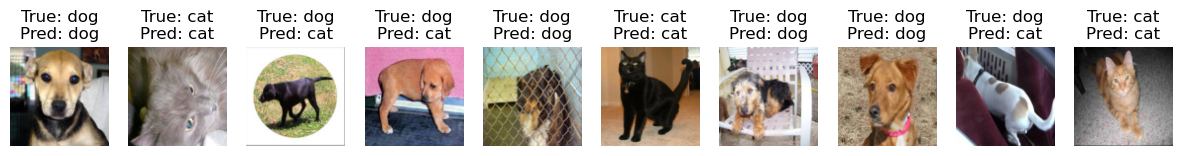

In [9]:
visualize_batch_predictions(model_dnn, test_loader, DEVICE, class_names=['cat', 'dog'], n_images=10)

In [10]:
# CNN 함수
class CNN_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.adaptive_pool = nn.AdaptiveMaxPool2d((7, 7))
        self.fc1 = nn.Linear(32 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = F.relu(x)
        out = self.fc2(x)

        return out

In [11]:
# 모델 학습 전 컴파일
model_cnn = CNN_Model().to(DEVICE)
opt = optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

In [12]:
# 메인 함수
for i in range(1, EPOCHS + 1):
    train(model_cnn, train_loader, opt, i)
    val_loss, val_accuracy = evaluate(model_cnn, val_loader)
    scheduler.step()
    print(f'epoch: {i}, val_loss: {val_loss:.3f}, val_accuracy: {val_accuracy:.3f}, lr: {scheduler.get_last_lr()[0]}')

print("\n--- 최종 테스트 평가 ---")
final_loss, final_accuracy = evaluate(model_cnn, test_loader)
print(f'Final Test Loss: {final_loss:.3f}, Final Test Accuracy: {final_accuracy:.3f}')

epoch: 1, val_loss: 0.682, val_accuracy: 58.053, lr: 0.01
epoch: 2, val_loss: 0.634, val_accuracy: 65.627, lr: 0.01
epoch: 3, val_loss: 0.583, val_accuracy: 68.907, lr: 0.001
epoch: 4, val_loss: 0.573, val_accuracy: 70.213, lr: 0.001
epoch: 5, val_loss: 0.568, val_accuracy: 70.507, lr: 0.001
epoch: 6, val_loss: 0.568, val_accuracy: 71.120, lr: 0.0001
epoch: 7, val_loss: 0.562, val_accuracy: 70.853, lr: 0.0001
epoch: 8, val_loss: 0.560, val_accuracy: 71.387, lr: 0.0001
epoch: 9, val_loss: 0.560, val_accuracy: 71.333, lr: 1e-05
epoch: 10, val_loss: 0.560, val_accuracy: 71.440, lr: 1e-05

--- 최종 테스트 평가 ---
Final Test Loss: 0.546, Final Test Accuracy: 72.507


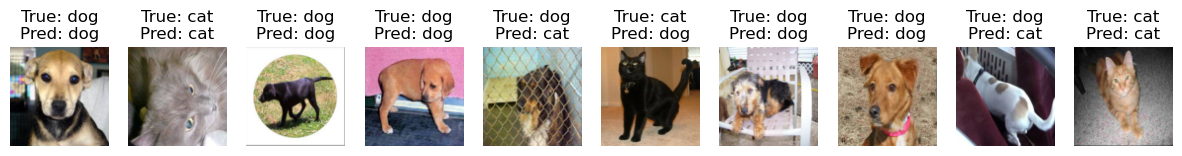

In [13]:
visualize_batch_predictions(model_cnn, test_loader, DEVICE, class_names=['cat', 'dog'], n_images=10)